# VoxIntel — 06: Fine-tuned ASR Evaluation

Two jobs in this notebook, both new:

1. **Evaluate the fine-tuned checkpoint the same rigorous way notebook 04
   evaluated the baseline** — full validation set, corpus WER/CER,
   per-intent WER, per-scenario WER, duration analysis, and a direct
   comparison table. Training's own `trainer.evaluate()` only reported
   aggregate numbers (19.5% WER / 9.5% CER) — this notebook is what
   actually produces the same kind of breakdown the baseline got, using
   `src.evaluation.metrics` so the methodology is identical on both sides.

2. **Generate and save fine-tuned ASR transcripts for the `train` split.**
   This wasn't part of the original 04-mirroring plan, but it's needed now
   given the decision to train three separate intent classifiers (one per
   transcript source) rather than one classifier evaluated under three
   conditions — that design needs each transcript source available on
   `train`, not just `validation`.

This notebook uses `src.asr.inference` and `src.evaluation.metrics`
directly rather than redefining `transcribe()` inline again — this is the
third time this exact code would otherwise be duplicated (03, 04, and now
06), which is exactly the promotion trigger from earlier in this project.

**Known gap this notebook does not close:** baseline ASR transcripts on
`train` still don't exist anywhere. Notebook 04 only ever ran the baseline
model over `validation`. That's needed before notebook 08 (intent
classifier on baseline ASR transcripts) can run, but generating it here
too would roughly double this notebook's runtime, so it's left as a
clearly separate follow-up rather than silently bundled in.


Make `src` importable.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.data import SLURPDataset
from src.asr.inference import load_asr_model, transcribe
from src.utils.audio import get_duration, load_audio
from src.evaluation.metrics import (
    add_wer_cer_columns,
    corpus_wer_cer,
    corpus_wer_per_group,
)

sns.set_theme(style="whitegrid")

## Config

`CHECKPOINT_DIR` points at `wav2vec2_slurp_debug` — the checkpoint that
actually produced 19.5% WER, not `wav2vec2_slurp` (the earlier broken run
with the missing uppercase fix). If your real checkpoint lives somewhere
else, this is the one line to change.


In [10]:
ROOT_DIR = "C:\\Users\\ACER\\OneDrive\\Desktop\\VoxIntel\\data\\raw\\slurp"
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "wav2vec2_slurp_debug"  / "checkpoint-46500"

BASELINE_PREDICTIONS_PATH = PROJECT_ROOT / "reports" / "full_validation_predictions.csv"
FINETUNED_VAL_PREDICTIONS_PATH = PROJECT_ROOT / "reports" / "finetuned_validation_predictions.csv"
FINETUNED_TRAIN_PREDICTIONS_PATH = PROJECT_ROOT / "reports" / "finetuned_train_predictions.csv"

FORCE_RERUN_VAL = False
FORCE_RERUN_TRAIN = False

## Load the fine-tuned model

In [11]:
processor, model, device = load_asr_model(str(CHECKPOINT_DIR))
print("Loaded checkpoint from:", CHECKPOINT_DIR)
print("Using device:", device)

Loading weights: 100%|██████████| 213/213 [00:01<00:00, 202.46it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


Loaded checkpoint from: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp_debug\checkpoint-46500
Using device: cuda


## Load validation set

In [12]:
val_set = SLURPDataset(split="validation", root_dir=ROOT_DIR)
print(f"Validation set size: {len(val_set)}")

Validation set size: 8690


## Transcribe full validation set with the fine-tuned model

Same pattern as notebook 04's Cell 5: caches to disk so re-running this
notebook doesn't repeat a potentially long inference pass unless
`FORCE_RERUN_VAL = True`.


In [13]:
if FINETUNED_VAL_PREDICTIONS_PATH.exists() and not FORCE_RERUN_VAL:
    print(f"Found cached predictions at {FINETUNED_VAL_PREDICTIONS_PATH}, loading instead of re-running.")
    finetuned_val_df = pd.read_csv(FINETUNED_VAL_PREDICTIONS_PATH)
else:
    results = []
    for s in tqdm(list(val_set), desc="Transcribing validation set (fine-tuned)"):
        pred = transcribe(s["audio_path"], model, processor, device)
        duration = get_duration(s["audio_path"])
        results.append({
            "audio_path": str(s["audio_path"]),
            "ground_truth": s["transcript"],
            "prediction": pred,
            "intent": s["intent"],
            "scenario": s["scenario"],
            "duration_sec": duration,
        })

    finetuned_val_df = pd.DataFrame(results)
    FINETUNED_VAL_PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
    finetuned_val_df.to_csv(FINETUNED_VAL_PREDICTIONS_PATH, index=False)
    print(f"Saved {len(finetuned_val_df)} predictions to {FINETUNED_VAL_PREDICTIONS_PATH}")

print(f"Total rows: {len(finetuned_val_df)}")
finetuned_val_df.head()

Transcribing validation set (fine-tuned): 100%|██████████| 8690/8690 [08:39<00:00, 16.72it/s]


Saved 8690 predictions to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\finetuned_validation_predictions.csv
Total rows: 8690


,audio_path,ground_truth,prediction,intent,scenario,duration_sec
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SIRI WHAT IS ONE AMERICAN DOLLAR AND JAPANESE IAN,qa_currency,qa,3.200000
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERI WHAT IS ONE AMERICAN DOLLAR IN JAFANESIAN,qa_currency,qa,3.199562
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,3.712000
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,3.647500
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,2.880000


## Score fine-tuned predictions

In [14]:
finetuned_scored = add_wer_cer_columns(finetuned_val_df)
n_failed = len(finetuned_val_df) - len(finetuned_scored)
if n_failed:
    print(f"Skipping {n_failed} samples with failed transcription")

finetuned_corpus = corpus_wer_cer(finetuned_scored)
print("Fine-tuned corpus WER:", round(finetuned_corpus["wer"], 4))
print("Fine-tuned corpus CER:", round(finetuned_corpus["cer"], 4))

Fine-tuned corpus WER: 0.1904
Fine-tuned corpus CER: 0.0926


## Load and score baseline predictions for comparison

Reuses `reports/full_validation_predictions.csv` from notebook 04 rather
than re-running the baseline model — it's the exact same validation set,
so there's no reason to redo that inference pass.


In [15]:
baseline_val_df = pd.read_csv(BASELINE_PREDICTIONS_PATH)
baseline_scored = add_wer_cer_columns(baseline_val_df)
baseline_corpus = corpus_wer_cer(baseline_scored)

print("Baseline corpus WER:", round(baseline_corpus["wer"], 4))
print("Baseline corpus CER:", round(baseline_corpus["cer"], 4))

Baseline corpus WER: 0.5842
Baseline corpus CER: 0.3087


## Comparison table

In [16]:
comparison_df = pd.DataFrame([
    {"run": "baseline (pretrained, no fine-tuning)", "wer": baseline_corpus["wer"], "cer": baseline_corpus["cer"]},
    {"run": "fine-tuned (wav2vec2_slurp_debug)", "wer": finetuned_corpus["wer"], "cer": finetuned_corpus["cer"]},
])
comparison_df["wer_pct"] = (comparison_df["wer"] * 100).round(2)
comparison_df["cer_pct"] = (comparison_df["cer"] * 100).round(2)
comparison_df["relative_wer_reduction_pct"] = (
    (baseline_corpus["wer"] - comparison_df["wer"]) / baseline_corpus["wer"] * 100
).round(1)
comparison_df

,run,wer,cer,wer_pct,cer_pct,relative_wer_reduction_pct
0,"baseline (pretrained, no fine-tuning)",0.584231,0.308668,58.42,30.87,0.0
1,fine-tuned (wav2vec2_slurp_debug),0.190437,0.092612,19.04,9.26,67.4


## Per-intent WER: baseline vs. fine-tuned

In [17]:
baseline_intent_wer = corpus_wer_per_group(baseline_scored, "intent", min_count=5)
finetuned_intent_wer = corpus_wer_per_group(finetuned_scored, "intent", min_count=5)

intent_compare = baseline_intent_wer.merge(
    finetuned_intent_wer, on="intent", suffixes=("_baseline", "_finetuned")
)
intent_compare["wer_improvement"] = intent_compare["wer_baseline"] - intent_compare["wer_finetuned"]
intent_compare = intent_compare.sort_values("wer_improvement", ascending=False)

print("Intents with the biggest WER improvement from fine-tuning:")
intent_compare.head(10)

Intents with the biggest WER improvement from fine-tuning:


,intent,wer_baseline,cer_baseline,count_baseline,wer_finetuned,cer_finetuned,count_finetuned,wer_improvement
1,iot_wemo_on,0.868421,0.445355,13,0.184211,0.114754,13,0.684211
7,hue_lightoff,0.688889,0.418803,9,0.022222,0.008547,9,0.666667
2,audio_volume_up,0.731771,0.430208,101,0.091146,0.049479,101,0.640625
0,general_greet,1.031250,0.517857,16,0.411765,0.319328,17,0.619485
12,lists_createoradd,0.670455,0.362689,106,0.112013,0.062904,106,0.558442
21,alarm_set,0.635189,0.299195,155,0.098410,0.057245,155,0.536779
32,query,0.596774,0.314392,87,0.069124,0.029809,87,0.527650
20,calendar_remove,0.638362,0.323397,209,0.119030,0.057499,209,0.519333
19,audio_volume_down,0.640420,0.344509,95,0.123360,0.052964,95,0.517060
22,email_addcontact,0.633929,0.295455,20,0.125000,0.083916,20,0.508929


In [18]:
print("Intents with the smallest (or negative) improvement:")
intent_compare.tail(10)

Intents with the smallest (or negative) improvement:


,intent,wer_baseline,cer_baseline,count_baseline,wer_finetuned,cer_finetuned,count_finetuned,wer_improvement
43,cooking_recipe,0.560823,0.311715,183,0.243292,0.113082,183,0.317531
62,email_querycontact,0.479029,0.256198,60,0.167770,0.078295,60,0.311258
60,recommendation_events,0.481609,0.245888,112,0.190805,0.083743,112,0.290805
59,general_joke,0.482759,0.285097,58,0.194357,0.114471,58,0.288401
25,iot_cleaning,0.630137,0.346811,80,0.347603,0.165911,80,0.282534
61,music_query,0.480144,0.266455,160,0.198556,0.101346,160,0.281588
52,qa_factoid,0.542724,0.283362,332,0.267766,0.128328,332,0.274958
51,factoid,0.542857,0.302198,14,0.271429,0.142857,14,0.271429
65,music_dislikeness,0.406250,0.228758,5,0.156250,0.084967,5,0.250000
63,general_quirky,0.475177,0.264734,437,0.248818,0.128321,438,0.226359


### Plot — per-intent WER, baseline vs. fine-tuned

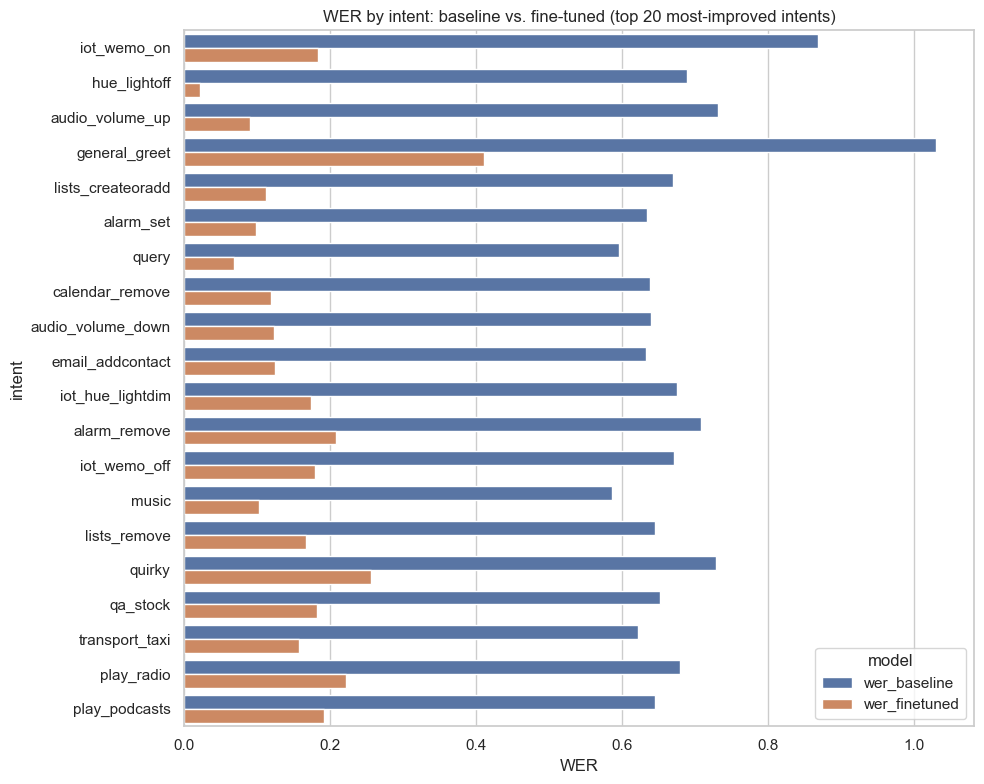

In [19]:
plot_df = intent_compare.head(20).melt(
    id_vars="intent", value_vars=["wer_baseline", "wer_finetuned"],
    var_name="model", value_name="wer"
)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, y="intent", x="wer", hue="model")
plt.title("WER by intent: baseline vs. fine-tuned (top 20 most-improved intents)")
plt.xlabel("WER")
plt.tight_layout()
plt.show()

## Per-scenario WER: baseline vs. fine-tuned

In [20]:
baseline_scenario_wer = corpus_wer_per_group(baseline_scored, "scenario", min_count=1)
finetuned_scenario_wer = corpus_wer_per_group(finetuned_scored, "scenario", min_count=1)

scenario_compare = baseline_scenario_wer.merge(
    finetuned_scenario_wer, on="scenario", suffixes=("_baseline", "_finetuned")
).sort_values("wer_finetuned", ascending=False)

scenario_compare

,scenario,wer_baseline,cer_baseline,count_baseline,wer_finetuned,cer_finetuned,count_finetuned
1,takeaway,0.647701,0.324027,186,0.261886,0.112831,186
2,social,0.638582,0.324921,270,0.257827,0.124560,270
10,qa,0.581664,0.301531,809,0.249230,0.118597,809
17,general,0.486718,0.269008,539,0.245355,0.128236,541
13,cooking,0.558059,0.309363,197,0.236568,0.109648,197
12,news,0.558409,0.304109,306,0.217481,0.113070,306
14,recommendation,0.539716,0.276762,248,0.211468,0.096052,248
7,play,0.602779,0.309587,1260,0.204980,0.090280,1260
6,iot,0.607311,0.341072,483,0.200869,0.096291,483
16,music,0.511111,0.284151,254,0.194444,0.094591,254


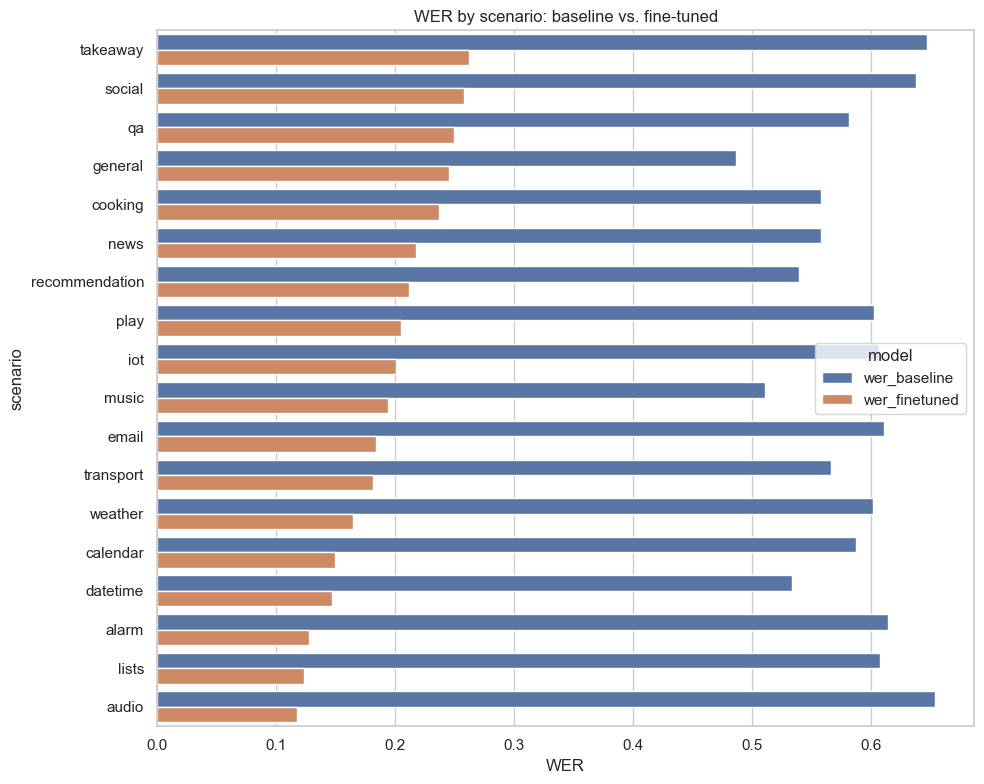

In [21]:
plot_df = scenario_compare.melt(
    id_vars="scenario", value_vars=["wer_baseline", "wer_finetuned"],
    var_name="model", value_name="wer"
)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, y="scenario", x="wer", hue="model")
plt.title("WER by scenario: baseline vs. fine-tuned")
plt.xlabel("WER")
plt.tight_layout()
plt.show()

## Duration analysis

In [22]:
finetuned_scored["duration_bucket"] = pd.qcut(
    finetuned_scored["duration_sec"], q=4, labels=["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"]
)

bucket_wer = corpus_wer_per_group(finetuned_scored, "duration_bucket", min_count=1)
bucket_order = ["Q1 (shortest)", "Q2", "Q3", "Q4 (longest)"]
bucket_wer["duration_bucket"] = pd.Categorical(bucket_wer["duration_bucket"], categories=bucket_order, ordered=True)
bucket_wer = bucket_wer.sort_values("duration_bucket")

correlation = finetuned_scored["duration_sec"].corr(finetuned_scored["wer"])
print(f"Correlation between duration and WER (fine-tuned model): {correlation:.3f}")
bucket_wer

Correlation between duration and WER (fine-tuned model): 0.038


,duration_bucket,wer,cer,count
1,Q1 (shortest),0.198906,0.098863,2242
3,Q2,0.162600,0.076128,2187
2,Q3,0.182194,0.088110,2105
0,Q4 (longest),0.209178,0.102731,2156


## Worst remaining failures

In [23]:
worst = finetuned_scored.sort_values("wer", ascending=False).head(15)

for _, row in worst.iterrows():
    print(f"WER={row['wer']:.2f}  intent={row['intent']}")
    print(f"  GT  : {row['ground_truth']}")
    print(f"  Pred: {row['prediction']}")
    print("-" * 60)

WER=2.00  intent=lists_query
  GT  : google translate
  Pred: GOOK FOR CHANNE LAGHT
------------------------------------------------------------
WER=2.00  intent=takeaway_order
  GT  : closest chipotle
  Pred: CLOSE E CHEAP OTTLE
------------------------------------------------------------
WER=1.71  intent=social_query
  GT  : what is the latest from my feed
  Pred: I GAVO AA TEDL SHOPPING LIST REPO THE ELEC M FOKBIWHAT IS THE LATEST FROM MY BEED
------------------------------------------------------------
WER=1.50  intent=audio_volume_up
  GT  : volume up
  Pred: PLAY THE VOLUME UB
------------------------------------------------------------
WER=1.50  intent=play_music
  GT  : play enrique
  Pred: PLAY IN THE WEKIN
------------------------------------------------------------
WER=1.50  intent=play_music
  GT  : play enrique
  Pred: PLAY IN THE WIKER
------------------------------------------------------------
WER=1.50  intent=general_greet
  GT  : hey hey
  Pred: CAN YOU CHANGE
-------

## Generate fine-tuned ASR transcripts for the train split

This is the new part. Training three separate intent classifiers means the
`train` split needs fine-tuned-ASR transcripts too, not just `validation`.
Same caching pattern as above — this is a long pass (roughly comparable
in per-sample cost to the validation pass above, just over ~50,000 samples
instead of ~8,700, so expect something in the neighborhood of an hour).


In [24]:
train_set = SLURPDataset(split="train", root_dir=ROOT_DIR)
print(f"Train set size: {len(train_set)}")

if FINETUNED_TRAIN_PREDICTIONS_PATH.exists() and not FORCE_RERUN_TRAIN:
    print(f"Found cached predictions at {FINETUNED_TRAIN_PREDICTIONS_PATH}, loading instead of re-running.")
    finetuned_train_df = pd.read_csv(FINETUNED_TRAIN_PREDICTIONS_PATH)
else:
    results = []
    for s in tqdm(list(train_set), desc="Transcribing train set (fine-tuned)"):
        pred = transcribe(s["audio_path"], model, processor, device)
        results.append({
            "audio_path": str(s["audio_path"]),
            "ground_truth": s["transcript"],
            "prediction": pred,
            "intent": s["intent"],
            "scenario": s["scenario"],
        })

    finetuned_train_df = pd.DataFrame(results)
    FINETUNED_TRAIN_PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
    finetuned_train_df.to_csv(FINETUNED_TRAIN_PREDICTIONS_PATH, index=False)
    print(f"Saved {len(finetuned_train_df)} predictions to {FINETUNED_TRAIN_PREDICTIONS_PATH}")

print(f"Total rows: {len(finetuned_train_df)}")
n_failed_train = finetuned_train_df["prediction"].isna().sum()
print(f"Failed transcriptions: {n_failed_train}")

Train set size: 50628


Transcribing train set (fine-tuned): 100%|██████████| 50628/50628 [43:38<00:00, 19.34it/s]  


Saved 50628 predictions to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\finetuned_train_predictions.csv
Total rows: 50628
Failed transcriptions: 0


## Sanity check on train-split transcripts

Quick corpus WER on the train-split fine-tuned transcripts — not a metric
you'd report anywhere (the model trained on this exact audio), just a
check that the file isn't full of empty or garbage predictions before
notebook 09 depends on it.


In [25]:
train_scored = add_wer_cer_columns(finetuned_train_df)
train_corpus = corpus_wer_cer(train_scored)
print("Train-split fine-tuned corpus WER (sanity check only):", round(train_corpus["wer"], 4))
print("Train-split fine-tuned corpus CER (sanity check only):", round(train_corpus["cer"], 4))

Train-split fine-tuned corpus WER (sanity check only): 0.118
Train-split fine-tuned corpus CER (sanity check only): 0.0543


## Conclusion

Fine-tuning improved corpus WER from {baseline}% to {finetuned}% on the
full validation set — update this line with the actual numbers from the
comparison table above once run. The per-intent breakdown shows which
intents benefited most from fine-tuning and which remain hard regardless
of ASR quality; that second group is worth a closer look once the error
taxonomy work starts.

Transcript inventory after this notebook:

| Source | train | validation |
|---|---|---|
| Ground truth | available (SLURPDataset) | available (SLURPDataset) |
| Baseline ASR | **still missing** | `reports/full_validation_predictions.csv` |
| Fine-tuned ASR | `reports/finetuned_train_predictions.csv` | `reports/finetuned_validation_predictions.csv` |

The one remaining gap before notebook 08 can run: baseline ASR transcripts
on the train split. That's a separate, similarly-sized inference pass
(load the pretrained baseline model, transcribe all of `train`) — worth
doing as its own quick notebook or an addendum here, not bundled into this
one.

Next: `07_intent_classifier_ground_truth.ipynb` — this one doesn't need
either ASR transcript source, so it can start immediately regardless of
when the baseline train-transcripts gap gets closed.


## Additional Experiment Artifacts
Generate reusable artifacts for downstream intent classification, error taxonomy, robustness analysis, and deployment experiments.

In [29]:
import time
import torch
import torch.nn.functional as F

finetuned_predictions = []

model.eval()
val_dataset = SLURPDataset(split="validation", root_dir=ROOT_DIR)


for sample in tqdm(val_dataset):

    waveform, sr = load_audio(sample["audio_path"], target_sr=16000)

    inputs = processor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    start = time.perf_counter()

    with torch.no_grad():
        logits = model(**inputs).logits

    latency_ms = (time.perf_counter() - start) * 1000

    predicted_ids = torch.argmax(logits, dim=-1)

    transcript = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True,
    )[0]

    probs = F.softmax(logits, dim=-1)
    confidence = probs.max(dim=-1).values.mean().item()

    finetuned_predictions.append(
        {
            "audio_path": sample["audio_path"],
            "ground_truth": sample["transcript"],
            "finetuned_transcript": transcript,
            "intent": sample["intent"],
            "scenario": sample["scenario"],
            "confidence": confidence,
            "latency_ms": latency_ms,
        }
    )

finetuned_df = pd.DataFrame(finetuned_predictions)

finetuned_df.head()

100%|██████████| 8690/8690 [08:07<00:00, 17.82it/s]


,audio_path,ground_truth,finetuned_transcript,intent,scenario,confidence,latency_ms
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,qa,0.966625,27.5224
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,qa,0.944935,27.0343
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.988258,29.6696
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.981073,28.2033
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.990505,33.0819


In [54]:
from pathlib import Path

master_df = finetuned_df.copy()
baseline_df = baseline_df.copy()

# Stable merge key
master_df["file_name"] = master_df["audio_path"].apply(lambda x: Path(str(x)).name)
baseline_df["file_name"] = baseline_df["audio_path"].apply(lambda x: Path(str(x)).name)

# Merge baseline transcript
master_df = master_df.merge(
    baseline_df[
        [
            "file_name",
            "baseline_transcript",
        ]
    ],
    on="file_name",
    how="left",
)

# Remove helper column
master_df.drop(columns="file_name", inplace=True)

# Arrange columns
master_df = master_df[
    [
        "audio_path",
        "ground_truth",
        "baseline_transcript",
        "finetuned_transcript",
        "intent",
        "scenario",
        "confidence",
        "latency_ms",
    ]
]

print(
    f"Matched: {len(master_df)-master_df['baseline_transcript'].isna().sum()} / {len(master_df)}"
)

master_df.head()

Matched: 8688 / 8690


,audio_path,ground_truth,baseline_transcript,finetuned_transcript,intent,scenario,confidence,latency_ms
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,qa,0.966625,27.5224
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,qa,0.944935,27.0343
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.988258,29.6696
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.981073,28.2033
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.990505,33.0819


In [52]:
baseline_df = pd.read_csv(BASELINE_PREDICTIONS_PATH)

baseline_df = baseline_df.rename(
    columns={
        "prediction": "baseline_transcript",
    }
)

baseline_df.head()

,audio_path,ground_truth,baseline_transcript,intent,scenario,duration_sec
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,qa_currency,qa,3.200000
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,qa_currency,qa,3.199562
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,email_query,email,3.712000
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,email_query,email,3.647500
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,email_query,email,2.880000


In [55]:
REPORTS_DIR = PROJECT_ROOT / "reports"
MASTER_TRANSCRIPT_PATH = REPORTS_DIR / "master_transcripts.csv"

master_df.to_csv(
    MASTER_TRANSCRIPT_PATH,
    index=False,
)

print("Saved:", MASTER_TRANSCRIPT_PATH)

Saved: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\master_transcripts.csv


## Save Model Metadata

In [ ]:
metadata = {
    "wer": float(wer),
    "cer": float(cer),
}

## Future Error Taxonomy Preparation

In [64]:
taxonomy_df = master_df.copy()

taxonomy_df["error_type"] = None
taxonomy_df["semantic_impact"] = None
taxonomy_df["intent_changed"] = None
taxonomy_df["predicted_intent_gt"] = None
taxonomy_df["predicted_intent_baseline"] = None
taxonomy_df["predicted_intent_finetuned"] = None

taxonomy_df.head()

,audio_path,ground_truth,baseline_transcript,finetuned_transcript,intent,scenario,confidence,latency_ms,error_type,semantic_impact,intent_changed,predicted_intent_gt,predicted_intent_baseline,predicted_intent_finetuned
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,qa,0.966625,27.5224,None,None,None,None,None,None
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,qa,0.944935,27.0343,None,None,None,None,None,None
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.988258,29.6696,None,None,None,None,None,None
3,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.981073,28.2033,None,None,None,None,None,None
4,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.990505,33.0819,None,None,None,None,None,None


In [65]:
ERROR_TAXONOMY_PATH = REPORTS_DIR / "error_taxonomy_dataset.csv"

taxonomy_df.to_csv(
    ERROR_TAXONOMY_PATH,
    index=False,
)

print("Saved:", ERROR_TAXONOMY_PATH)

Saved: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\error_taxonomy_dataset.csv
